In [1]:
import nfl_data_py as nfl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
sns.set(style="whitegrid")


seasons = [2022, 2023, 2024]


pbp = nfl.import_pbp_data(seasons, downcast=True)


sched = nfl.import_schedules(seasons)


pbp = pbp[pbp["season_type"] == "REG"]
sched = sched[sched["game_type"] == "REG"]

pbp.head()



2022 done.
2023 done.
2024 done.
Downcasting floats.


,play_id,game_id,old_game_id_x,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,was_pressure,route,defense_man_zone_type,defense_coverage_type,offense_names,defense_names,offense_positions,defense_positions,offense_numbers,defense_numbers
0,1.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,None,None,None,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
1,43.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
2,68.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
3,89.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,True,ANGLE,ZONE_COVERAGE,COVER_2,NaN,NaN,NaN,NaN,NaN,NaN
4,115.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
pbp.head(20)


,play_id,game_id,old_game_id_x,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,was_pressure,route,defense_man_zone_type,defense_coverage_type,offense_names,defense_names,offense_positions,defense_positions,offense_numbers,defense_numbers
0,1.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,None,None,None,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
1,43.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
2,68.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
3,89.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,True,ANGLE,ZONE_COVERAGE,COVER_2,NaN,NaN,NaN,NaN,NaN,NaN
4,115.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
5,136.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,True,None,ZONE_COVERAGE,COVER_3,NaN,NaN,NaN,NaN,NaN,NaN
6,172.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
7,202.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,BAL,away,NYJ,...,False,CROSS,ZONE_COVERAGE,COVER_3,NaN,NaN,NaN,NaN,NaN,NaN
8,230.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,BAL,away,NYJ,...,False,HITCH,ZONE_COVERAGE,COVER_4,NaN,NaN,NaN,NaN,NaN,NaN
9,254.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,BAL,away,NYJ,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
team_game_stats = pbp.groupby(
    ["game_id", "posteam"]
).agg({
    "passing_yards": "sum",
    "rushing_yards": "sum",
    "pass_attempt": "sum",
    "rush_attempt": "sum",
    "yards_gained": "sum"
}).reset_index()

team_game_stats.rename(columns={
    "posteam": "team"
}, inplace=True)

team_game_stats.head()


,game_id,team,passing_yards,rushing_yards,pass_attempt,rush_attempt,yards_gained
0,2022_01_BAL_NYJ,BAL,213.0,63.0,32.0,21.0,274.0
1,2022_01_BAL_NYJ,NYJ,309.0,83.0,62.0,17.0,380.0
2,2022_01_BUF_LA,BUF,297.0,121.0,33.0,25.0,413.0
3,2022_01_BUF_LA,LA,240.0,52.0,48.0,18.0,243.0
4,2022_01_CLE_CAR,CAR,235.0,54.0,31.0,19.0,261.0


In [4]:
team_game_stats["PEI"] = team_game_stats["passing_yards"] / team_game_stats["pass_attempt"]
team_game_stats["REI"] = team_game_stats["rushing_yards"] / team_game_stats["rush_attempt"]
team_game_stats["OBR"] = team_game_stats["pass_attempt"] / (
    team_game_stats["pass_attempt"] + team_game_stats["rush_attempt"]
)
team_game_stats.head()


,game_id,team,passing_yards,rushing_yards,pass_attempt,rush_attempt,yards_gained,PEI,REI,OBR
0,2022_01_BAL_NYJ,BAL,213.0,63.0,32.0,21.0,274.0,6.656250,3.000000,0.603774
1,2022_01_BAL_NYJ,NYJ,309.0,83.0,62.0,17.0,380.0,4.983871,4.882353,0.784810
2,2022_01_BUF_LA,BUF,297.0,121.0,33.0,25.0,413.0,9.000000,4.840000,0.568965
3,2022_01_BUF_LA,LA,240.0,52.0,48.0,18.0,243.0,5.000000,2.888889,0.727273
4,2022_01_CLE_CAR,CAR,235.0,54.0,31.0,19.0,261.0,7.580645,2.842105,0.620000


In [5]:
sched_small = sched[["game_id", "home_team", "away_team", "home_score", "away_score"]]

sched_small["winner"] = sched_small.apply(
    lambda row: row["home_team"] if row["home_score"] > row["away_score"] else row["away_team"],
    axis=1
)

# Win flag
team_game_stats["win"] = team_game_stats.apply(
    lambda row: 1 if row["team"] == sched_small[sched_small["game_id"] == row["game_id"]]["winner"].values[0] else 0,
    axis=1
)

team_game_stats.head()


/var/folders/m9/dtjr3fhn0y1fyk0klql2m2p40000gn/T/ipykernel_57838/4089944902.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sched_small["winner"] = sched_small.apply(


,game_id,team,passing_yards,rushing_yards,pass_attempt,rush_attempt,yards_gained,PEI,REI,OBR,win
0,2022_01_BAL_NYJ,BAL,213.0,63.0,32.0,21.0,274.0,6.656250,3.000000,0.603774,1
1,2022_01_BAL_NYJ,NYJ,309.0,83.0,62.0,17.0,380.0,4.983871,4.882353,0.784810,0
2,2022_01_BUF_LA,BUF,297.0,121.0,33.0,25.0,413.0,9.000000,4.840000,0.568965,1
3,2022_01_BUF_LA,LA,240.0,52.0,48.0,18.0,243.0,5.000000,2.888889,0.727273,0
4,2022_01_CLE_CAR,CAR,235.0,54.0,31.0,19.0,261.0,7.580645,2.842105,0.620000,0


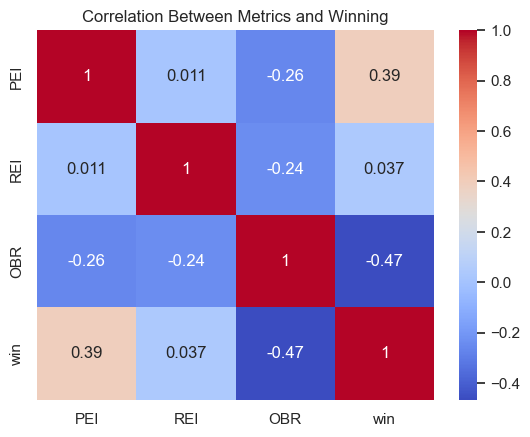

In [6]:
sns.heatmap(team_game_stats[["PEI", "REI", "OBR", "win"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Metrics and Winning")
plt.show()


In [7]:
team_game_stats.describe()


,passing_yards,rushing_yards,pass_attempt,rush_attempt,yards_gained,PEI,REI,OBR,win
count,1630.000000,1630.000000,1630.000000,1630.000000,1630.000000,1630.000000,1630.000000,1630.000000,1630.000000
mean,234.740494,118.001839,35.880981,27.100613,336.566864,6.632929,4.280659,0.569638,0.500000
std,71.437454,51.702843,8.375140,7.607285,82.839088,1.786393,1.252106,0.107166,0.500153
min,7.000000,3.000000,12.000000,6.000000,58.000000,0.388889,0.500000,0.193548,0.000000
25%,185.000000,78.000000,30.000000,22.000000,280.000000,5.401191,3.402273,0.492754,0.000000
50%,230.000000,112.000000,35.000000,26.000000,334.000000,6.469069,4.156250,0.571429,0.500000
75%,280.000000,150.000000,41.000000,32.000000,393.000000,7.709341,5.026520,0.644068,1.000000
max,509.000000,363.000000,72.000000,53.000000,726.000000,14.782609,9.652174,0.898305,1.000000


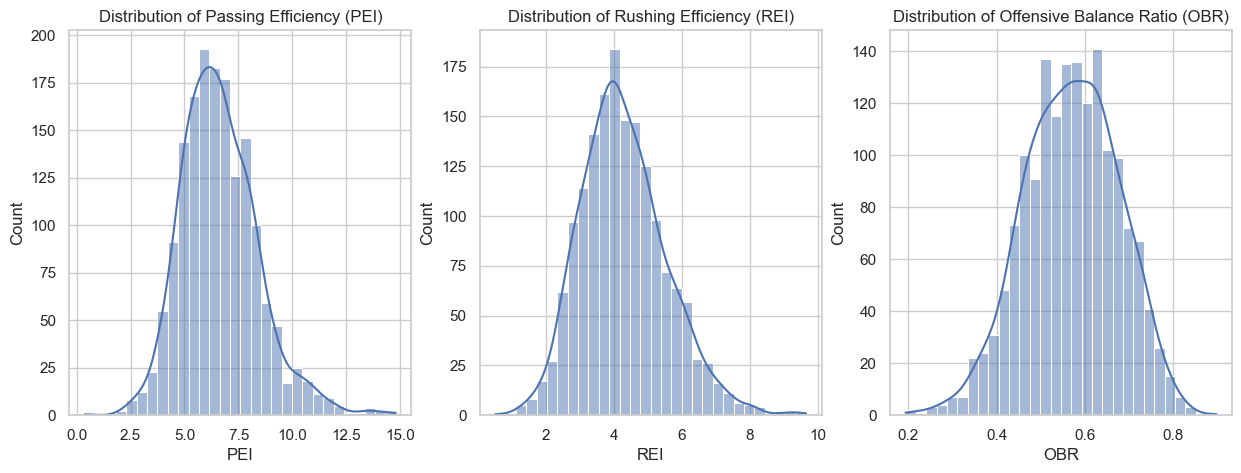

In [8]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(team_game_stats["PEI"], kde=True, bins=30)
plt.title("Distribution of Passing Efficiency (PEI)")

plt.subplot(1,3,2)
sns.histplot(team_game_stats["REI"], kde=True, bins=30)
plt.title("Distribution of Rushing Efficiency (REI)")

plt.subplot(1,3,3)
sns.histplot(team_game_stats["OBR"], kde=True, bins=30)
plt.title("Distribution of Offensive Balance Ratio (OBR)")

plt.show()


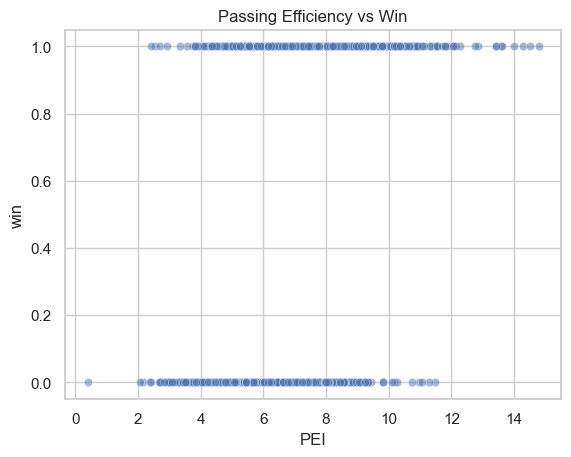

In [9]:
sns.scatterplot(x="PEI", y="win", data=team_game_stats, alpha=0.5)
plt.title("Passing Efficiency vs Win")
plt.show()


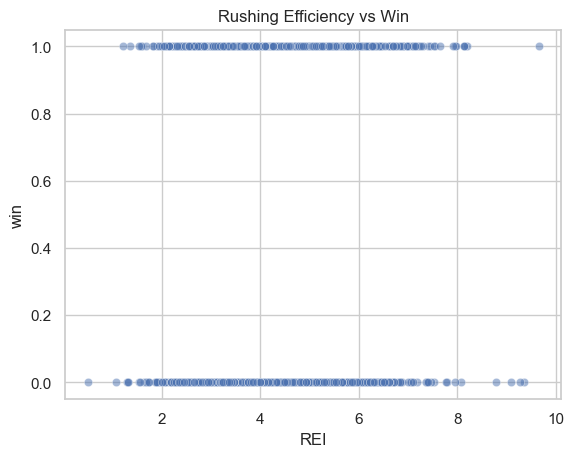

In [10]:
sns.scatterplot(x="REI", y="win", data=team_game_stats, alpha=0.5)
plt.title("Rushing Efficiency vs Win")
plt.show()


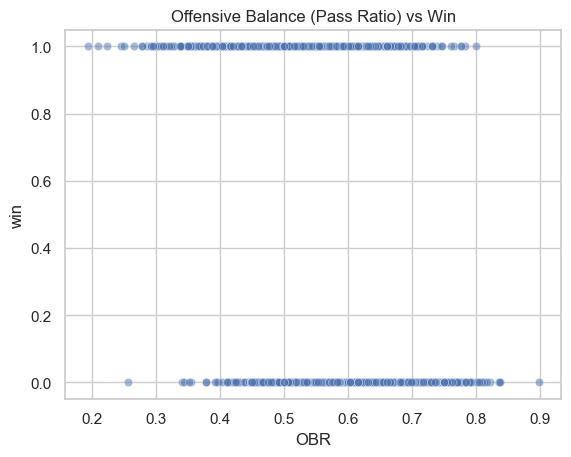

In [11]:
sns.scatterplot(x="OBR", y="win", data=team_game_stats, alpha=0.5)
plt.title("Offensive Balance (Pass Ratio) vs Win")
plt.show()


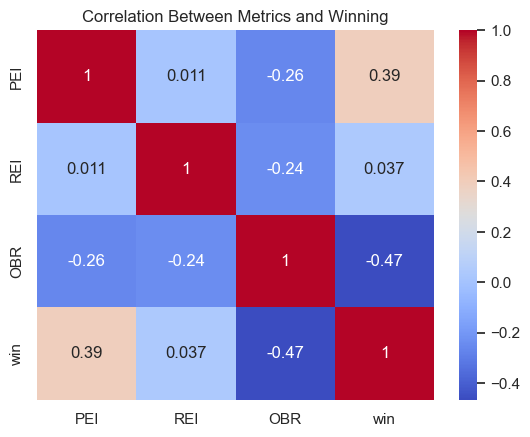

In [12]:
sns.heatmap(
    team_game_stats[["PEI", "REI", "OBR", "win"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Between Metrics and Winning")
plt.show()


In [13]:
from scipy.stats import ttest_ind

winners = team_game_stats[team_game_stats["win"] == 1]["PEI"]
losers  = team_game_stats[team_game_stats["win"] == 0]["PEI"]

t_stat, p_value = ttest_ind(winners, losers, equal_var=False)
t_stat, p_value


(np.float64(17.20363796728933), np.float64(7.041741917600833e-61))

In [14]:
winners = team_game_stats[team_game_stats["win"] == 1]["REI"]
losers  = team_game_stats[team_game_stats["win"] == 0]["REI"]

t_stat, p_value = ttest_ind(winners, losers, equal_var=False)
t_stat, p_value


(np.float64(1.489421509697032), np.float64(0.13657014178182905))

In [15]:
winners = team_game_stats[team_game_stats["win"] == 1]["OBR"]
losers  = team_game_stats[team_game_stats["win"] == 0]["OBR"]

t_stat, p_value = ttest_ind(winners, losers, equal_var=False)
t_stat, p_value

(np.float64(-21.2798927663911), np.float64(7.516455503237556e-89))

In [17]:

features = ["PEI", "REI", "OBR"]
X = team_game_stats[features]
y = team_game_stats["win"]

In [18]:
df[["PEI", "REI", "OBR", "win"]].head()


In [ ]:
globals().keys()


In [ ]:
!pip install scikit-learn


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
import sys
sys.executable

In [ ]:
import sys
!{sys.executable} -m pip install -U scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:




from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd


features = ["PEI", "REI", "OBR"]
X = team_game_stats[features]
y = team_game_stats["win"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

In [ ]:
globals().keys()

In [19]:
"team_game_stats" in globals()

True

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd


features = ["PEI", "REI", "OBR"]
X = team_game_stats[features].copy()
y = team_game_stats["win"].astype(int).copy()


X = X.replace([float("inf"), float("-inf")], pd.NA).dropna()
y = y.loc[X.index]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)


model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)


coef_table = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", ascending=False)

print("\nModel Coefficients (positive -> higher win probability):")
print(coef_table.to_string(index=False))

Accuracy: 0.7668711656441718

Confusion Matrix:
 [[190  55]
 [ 59 185]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.78      0.77       245
           1       0.77      0.76      0.76       244

    accuracy                           0.77       489
   macro avg       0.77      0.77      0.77       489
weighted avg       0.77      0.77      0.77       489


Model Coefficients (positive -> higher win probability):
feature  coefficient
    PEI     0.475129
    REI    -0.064421
    OBR    -6.370847
